# Business Case: Aerofit -  Descriptive Statistics & Probability

<h1>Table of Contents</n>
<h2>1. What does ‘good’ look like?</n>

*   <h6>Data Type of Columns.
*   <h6>Number of Rows & Columns.
*   <h6>Check for missing & null values.

<h2>2. Detect Outliers

*  <h6>Outliers for every continuous variable in the dataset.
*  <h6>Remove/clip the data between the 5 percentile and 95 percentile.

<h2>3. Check if features like marital status, Gender, and age have any effect    on the product
purchased

* <h6>Relationship between the categorical variables and the output
variable in the data.
* <h6>Relationship between the continuous variables and the output
variable in the data.

<h2>4. Representing the Probability

* <h6> The marginal probability for products KP281, KP481, or KP781.
* <h6> Probability that the customer buys a product based on each column.
* <h6> Conditional probability that an event occurs given that another event has
occurred.
<h2>5. Check the correlation among different factors

* <h6>The correlation between the given features in the table.
<h2>6. Customer profiling and recommendation

*  <h6>Make customer profilings for each and every product.
* <h6>detailed recommendation from the analysis that you have done.



<h1>Why this case study?

**From the company’s perspective:**

*   Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product
range including machines such as treadmills, exercise bikes, gym equipment, and
fitness accessories to cater to the needs of all categories of people.
*    The market research team at AeroFit wants to identify the characteristics of the target
audience for each type of treadmill offered by the company, to provide a better
recommendation of the treadmills to new customers. The team decides to investigate
whether there are differences across the product with respect to customer
characteristics.

*   Perform descriptive analytics to create a customer profile for each AeroFit treadmill
product by developing appropriate tables and charts.


*   Construct two-way contingency tables for each AeroFit treadmill product and compute
all conditional and marginal probabilities and their insights/impact on the business.






##  About Data 📚

The company collected the data on individuals who purchased a treadmill from the AeroFit stores during `three months`.The data is available in a single csv file

**Product Portfolio**

- The `KP281` is an `entry-level` treadmill that sells for `USD 1,500`.


- The `KP481` is for `mid-level` runners that sell for `USD 1,750`.


- The `KP781` treadmill is having `advanced features` that sell for `USD 2,500`.


##  Features of the dataset:


| Feature | Description |
|:--------|:------------|
| Product | Product Purchased:	`KP281`, `KP481`, or `KP781` |
| Age | Age of buyer in years |
| Gender | Gender of buyer (Male/Female) |
| Education | Education of buyer in years |
| MaritalStatus | MaritalStatus of buyer (Single or partnered) |
| Usage | The average number of times the buyer plans to use the treadmill each week |
| Income | Annual income of the buyer (in $) |
| Fitness | Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape |
| Miles | The average number of miles the buyer expects to walk/run each week |

**What does ‘good’ look like?**

<h4>1. Import the dataset and do usual data analysis steps like checking the structure &
characteristics of the dataset

*   <h5>The data type of all columns in the “customers” table.




In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import copy

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving aerofit_treadmill.csv to aerofit_treadmill.csv


In [ ]:
# loading the dataset
df = pd.read_csv('aerofit_treadmill.csv')

In [ ]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
df.tail()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
df.dtypes

,0
Product,object
Age,int64
Gender,object
Education,int64
MaritalStatus,object
Usage,int64
Fitness,int64
Income,int64
Miles,int64




*   <h5>You can find the number of rows and columns given in the dataset.



In [ ]:
df.shape

(180, 9)



*   <h5>Check for the missing values and find the number of missing values in each
column



In [ ]:
df.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
df.isna().sum()


,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

**2. Detect Outliers**

*   <h5>Find the outliers for every continuous variable in the dataset



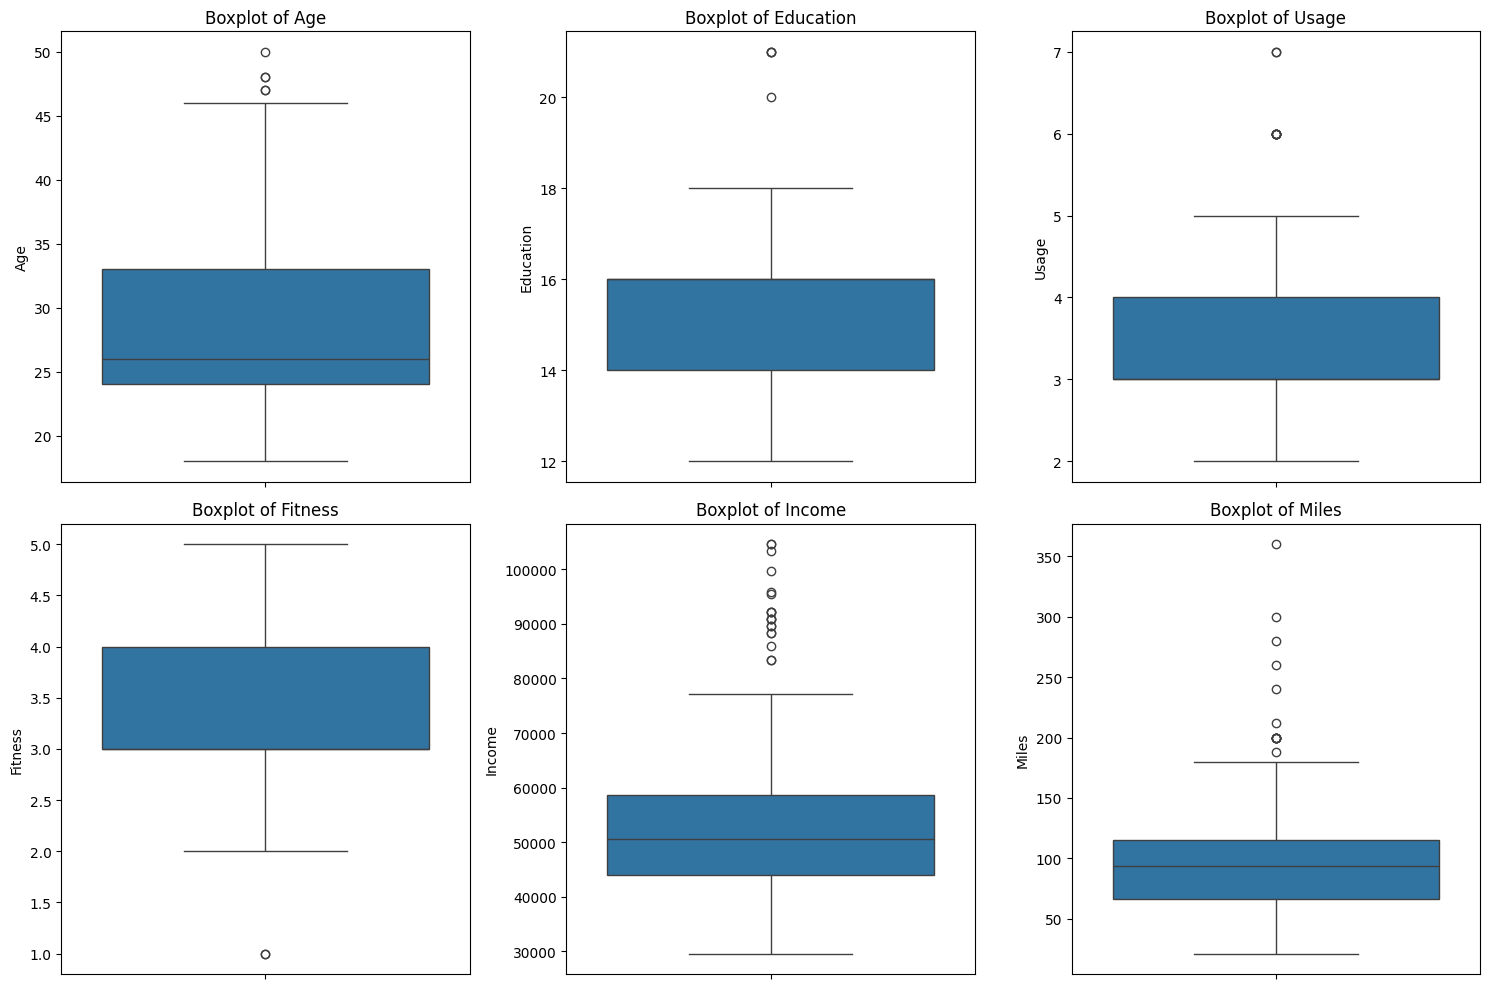

In [ ]:
continuous_var = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_var):
    plt.subplot(2, 3, i + 1)   # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[var])
    plt.title(f'Boxplot of {var}')
    plt.ylabel(var)
plt.tight_layout()
plt.show()

*   <h5>Remove/clip the data between the 5 percentile and 95 percentile



In [ ]:
# Clip the data for continuous variables between 5th and 95th percentiles
for var in continuous_var:
    lower_bound = df[var].quantile(0.05)
    upper_bound = df[var].quantile(0.95)
    df[var] = np.clip(df[var], lower_bound, upper_bound)
display(df.head())

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,20.0,Male,14,Single,3.0,4,34053.15,112
1,KP281,20.0,Male,15,Single,2.0,3,34053.15,75
2,KP281,20.0,Female,14,Partnered,4.0,3,34053.15,66
3,KP281,20.0,Male,14,Single,3.0,3,34053.15,85
4,KP281,20.0,Male,14,Partnered,4.0,2,35247.00,47


#### Now, let's re-check the boxplots to see the effect of clipping on outliers.

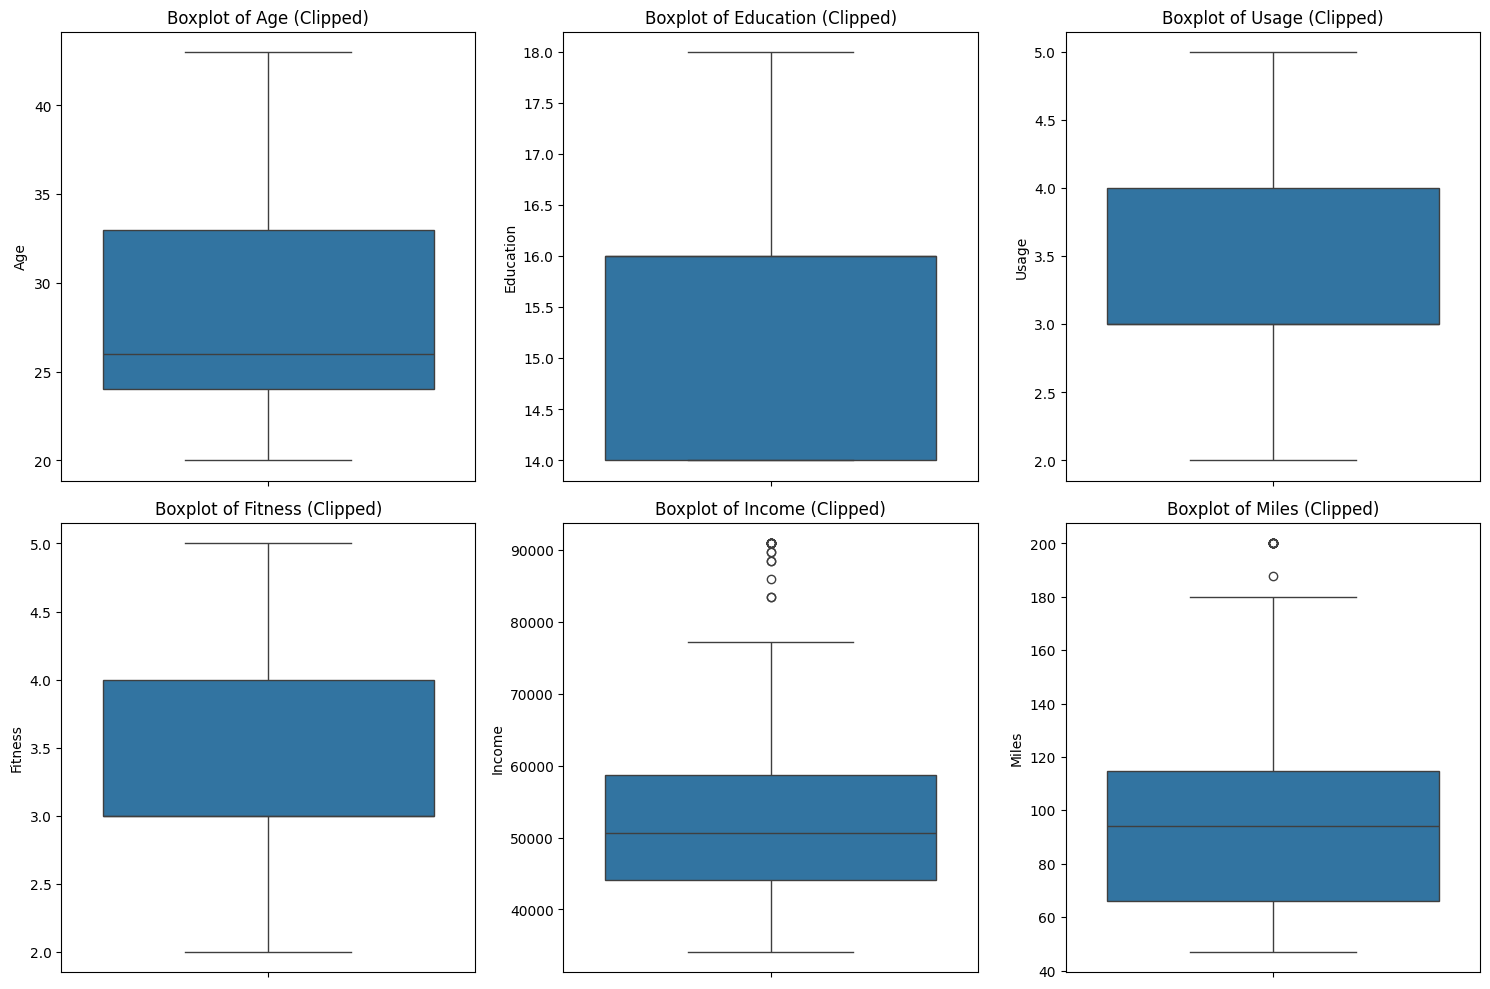

In [ ]:
plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_var):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[var])
    plt.title(f'Boxplot of {var} (Clipped)')
    plt.ylabel(var)
plt.tight_layout()
plt.show()

**3. Check if features like marital status, Gender, and age have any effect on the product
purchased**

*   <h5>Find if there is any relationship between the categorical variables and the output
variable in the data.



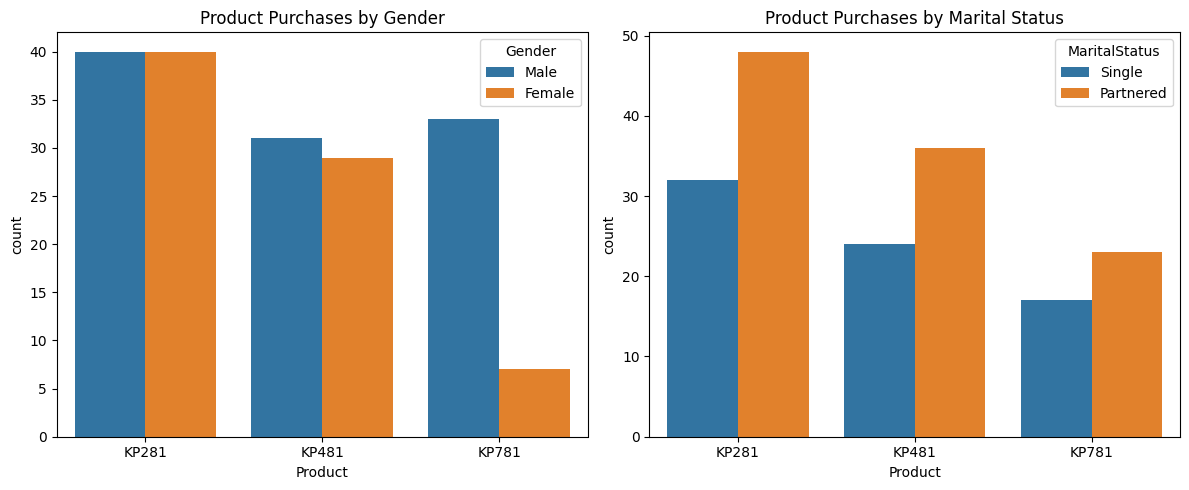

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Product', hue='Gender')
plt.title('Product Purchases by Gender')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Product', hue='MaritalStatus')
plt.title('Product Purchases by Marital Status')

plt.tight_layout()
plt.show()

*   <h5>Find if there is any relationship between the continuous variables and the output
variable in the data.



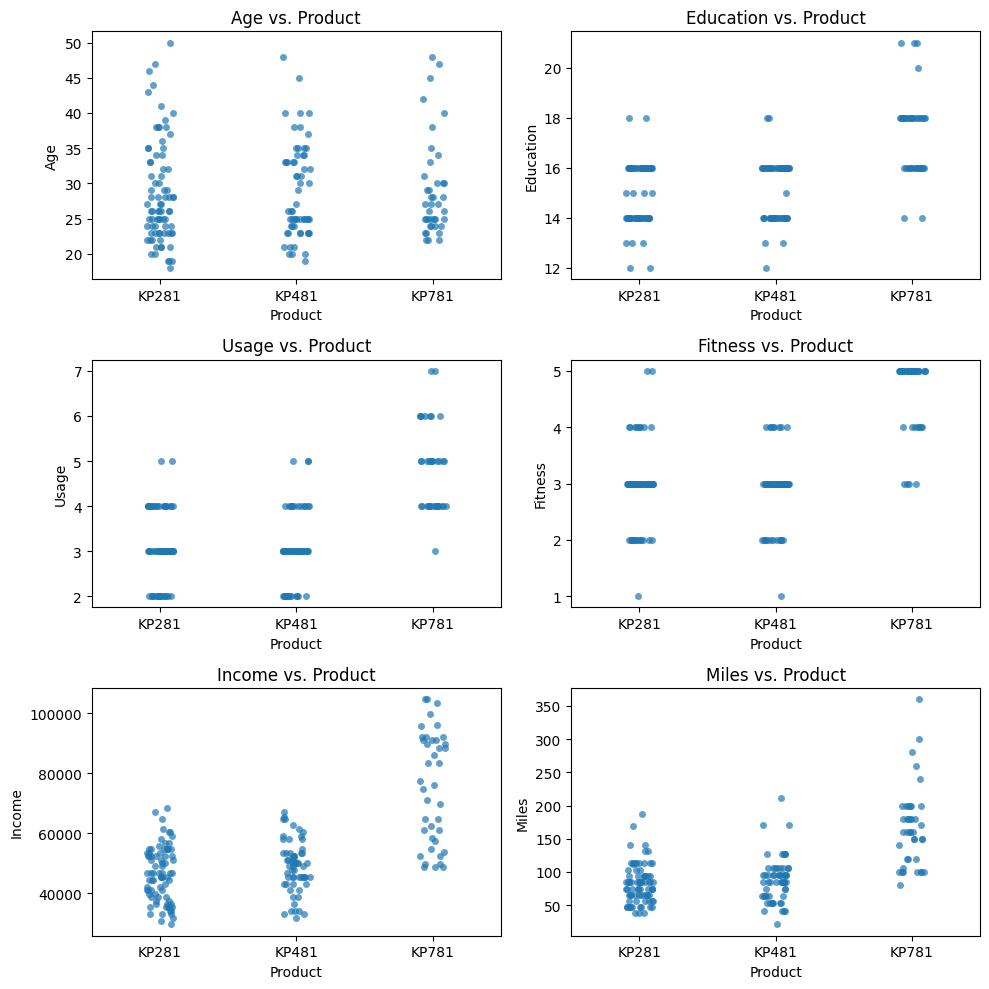

In [ ]:
plt.figure(figsize=(10, 10))
for i, var in enumerate(continuous_var):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 3x2 grid
    sns.stripplot(data=df, x='Product', y=var, jitter=True, alpha=0.7)
    plt.title(f'{var} vs. Product')
    plt.ylabel(var)
    plt.xlabel('Product')
plt.tight_layout()
plt.show()

**4. Representing the Probability**

*   <h5>Find the marginal probability (what percent of customers have purchased
KP281, KP481, or KP781)



In [ ]:
marginal_prob = pd.crosstab(index=df['Product'], columns='Probability', normalize=True)
marginal_percent = marginal_prob * 100
print(marginal_percent)

col_0    Probability
Product             
KP281      44.444444
KP481      33.333333
KP781      22.222222


* <h5>Find the probability that the customer buys a product based on each column.

<h6> 1. Probability of product purchase with respect to gender

In [ ]:
gender_product=pd.crosstab(index =df['Product'],columns = df['Gender'],margins = True,normalize = True ).round(2)
gender_product

Gender,Female,Male,All
Product,,,
KP281,0.22,0.22,0.44
KP481,0.16,0.17,0.33
KP781,0.04,0.18,0.22
All,0.42,0.58,1.00


<h6> 2.Probability of product purchase with respect to Age

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'],bins= [18,30,40,50,60,70], labels=['18-30', '31-40', '41-50', '51-60', '61-70'])
age_product = pd.crosstab (df['AgeGroup'], df['Product'], normalize='index') * 10
age_product.round(2)

Product,KP281,KP481,KP781
AgeGroup,,,
18-30,4.54,2.94,2.52
31-40,3.96,4.79,1.25
41-50,5.00,1.67,3.33


<h6> 3. Probability of product purchase with respect to Marital Status

In [ ]:
marital_product = pd.crosstab (df['MaritalStatus'], df ['Product'], normalize='index')
marital_product.round(2)

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,0.45,0.34,0.21
Single,0.44,0.33,0.23


<h6> 4. Probability of product purchase with respect to Weekly Usage

In [ ]:
pd.crosstab(index =df['Product'],columns = df['Usage'],margins = True,normalize = True ).round(2)

Usage,2,3,4,5,6,7,All
Product,,,,,,,
KP281,0.11,0.21,0.12,0.01,0.00,0.00,0.44
KP481,0.08,0.17,0.07,0.02,0.00,0.00,0.33
KP781,0.00,0.01,0.10,0.07,0.04,0.01,0.22
All,0.18,0.38,0.29,0.09,0.04,0.01,1.00


* <h5>Find the conditional probability that an event occurs given that another event has
occurred. (Example: given that a customer is female, what is the probability
she’ll purchase a KP481)

In [ ]:
P_KP481_and_Female = gender_product.loc['KP481', 'Female']
P_Female = gender_product.loc['All', 'Female']
prob_female_kp481 = (P_KP481_and_Female / P_Female) * 100 # Convert to percentage
print(f"\nP(Product=KP481 | Gender Female) = {prob_female_kp481:.2f}%")


P(Product=KP481 | Gender Female) = 38.10%


**5. Check the correlation among different factors**

* <h5>Find the correlation between the given features in the table.

In [ ]:
df['Usage'] = df['Usage'].astype('str')
df['Fitness'] = df['Fitness'].astype('str')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product        180 non-null    object 
 1   Age            180 non-null    float64
 2   Gender         180 non-null    object 
 3   Education      180 non-null    int64  
 4   MaritalStatus  180 non-null    object 
 5   Usage          180 non-null    object 
 6   Fitness        180 non-null    object 
 7   Income         180 non-null    float64
 8   Miles          180 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 12.8+ KB


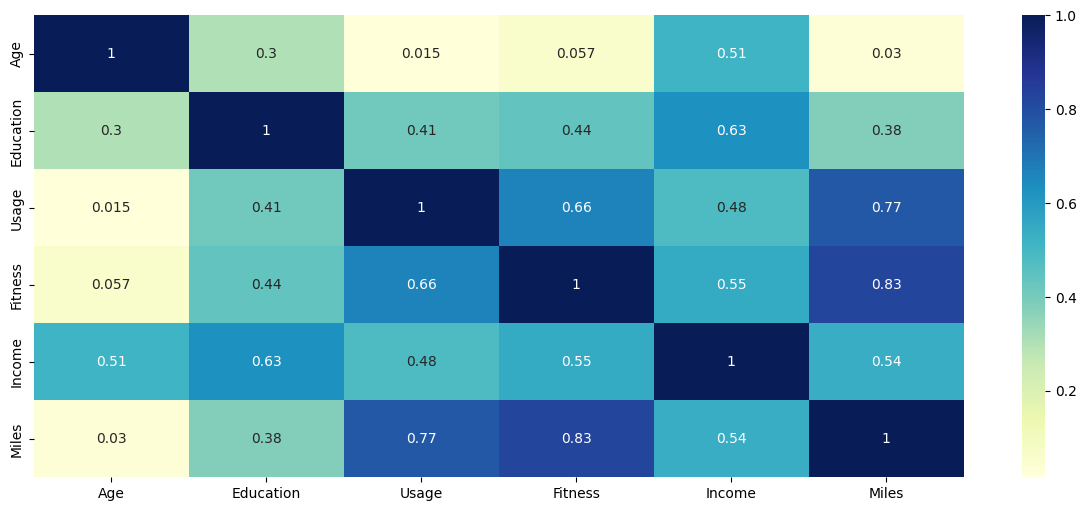

In [ ]:
df_copy = df.copy()
corr_mat = df_copy.corr(numeric_only=True)
plt.figure(figsize=(15,6))
sns.heatmap(corr_mat,annot = True, cmap="YlGnBu")
plt.show()

**6. Customer profiling and recommendation**

* <h5>Make customer profilings for each and every product.

### Customer Profile for KP281

In [ ]:
kp281_customers = df[df['Product'] == 'KP281']

print("KP281 Customer Profile:")
print("\nAge Distribution:")
print(kp281_customers['Age'].describe())

print("\nGender Distribution:")
print(kp281_customers['Gender'].value_counts(normalize=True) * 100)

print("\nIncome Distribution:")
print(kp281_customers['Income'].describe())

KP281 Customer Profile:

Age Distribution:
count    80.000000
mean     28.427500
std       6.678313
min      20.000000
25%      23.000000
50%      26.000000
75%      33.000000
max      43.050000
Name: Age, dtype: float64

Gender Distribution:
Gender
Male      50.0
Female    50.0
Name: proportion, dtype: float64

Income Distribution:
count       80.000000
mean     46584.311250
std       8813.246103
min      34053.150000
25%      38658.000000
50%      46617.000000
75%      53439.000000
max      68220.000000
Name: Income, dtype: float64


### Customer Profile for KP481

In [ ]:
kp481_customers = df[df['Product'] == 'KP481']

print("KP481 Customer Profile:")
print("\nAge Distribution:")
print(kp481_customers['Age'].describe())

print("\nGender Distribution:")
print(kp481_customers['Gender'].value_counts(normalize=True) * 100)

print("\nIncome Distribution:")
print(kp481_customers['Income'].describe())

KP481 Customer Profile:

Age Distribution:
count    60.000000
mean     28.801667
std       6.327830
min      20.000000
25%      24.000000
50%      26.000000
75%      33.250000
max      43.050000
Name: Age, dtype: float64

Gender Distribution:
Gender
Male      51.666667
Female    48.333333
Name: proportion, dtype: float64

Income Distribution:
count       60.000000
mean     49046.607500
std       8517.583361
min      34053.150000
25%      44911.500000
50%      49459.500000
75%      53439.000000
max      67083.000000
Name: Income, dtype: float64


### Customer Profile for KP781

In [ ]:
kp781_customers = df[df['Product'] == 'KP781']

print("KP781 Customer Profile:")
print("\nAge Distribution:")
print(kp781_customers['Age'].describe())

print("\nGender Distribution:")
print(kp781_customers['Gender'].value_counts(normalize=True) * 100)

print("\nIncome Distribution:")
print(kp781_customers['Income'].describe())

KP781 Customer Profile:

Age Distribution:
count    40.000000
mean     28.828750
std       6.296182
min      22.000000
25%      24.750000
50%      27.000000
75%      30.250000
max      43.050000
Name: Age, dtype: float64

Gender Distribution:
Gender
Male      82.5
Female    17.5
Name: proportion, dtype: float64

Income Distribution:
count       40.000000
mean     73908.281250
std      16572.164368
min      48556.000000
25%      58204.750000
50%      76568.500000
75%      90886.000000
max      90948.250000
Name: Income, dtype: float64


* <h5>Write a detailed recommendation from the analysis that you have done.

**Marketing Campaigns for KP781**

- The KP784 model exhibits a significant sales disparity in terms of gender, with only 18% of total sales attributed to female customers. To enhance this metric, it is recommended to implement targeted strategies such as offering special promotions and trials exclusively designed for the female customers.

**Affordable Pricing and Payment Plans**

- Given the target customer's age, education level, and income, it's important to offer the KP281 and KP481 Treadmill at an affordable price point. Additionally, consider providing flexible payment plans that allow customers to spread the cost over several months. This can make the treadmill more accessible to customers with varying budgets.

**User-Friendly App Integration**

- Create a user-friendly app that syncs with the treadmill. This app could track users' weekly running mileage, provide real-time feedback on their progress, and offer personalized recommendations for workouts based on their fitness scale and goals.This  can enhance the overall treadmill experience and keep users engaged.